# Data 620 Web Analytics
## Introduction & Research Question
### Author: Chi Hang (Philip) Cheung
### 3 Questions:
### 1) Do users who share hashtag communities on social media exhibit similar sentiment patterns?
### 2) Can we predict post sentiment from both textual content and social network position?
### 3) Can social network position predict user sentiment?

Data source: https://www.kaggle.com/datasets/kashishparmar02/social-media-sentiments-analysis-dataset

In [88]:
import networkx as nx
import pandas as pd
import os
from itertools import combinations
import kagglehub
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter
import community as community_louvain
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import f1_score
from scipy.stats import chi2_contingency
from sklearn.preprocessing import MaxAbsScaler

## Section 1: Data loading and cleaning

### Data loading

In [89]:
#Download the dataset:
dataset_path = kagglehub.dataset_download("kashishparmar02/social-media-sentiments-analysis-dataset")
print(f"Downloaded dataset path: {dataset_path}")
print(f"Contents of downloaded dataset path: {os.listdir(dataset_path)}")

# Adjust the file_name if it's different or nested in a subfolder
file_name = 'sentimentdataset.csv'
file_path = os.path.join(dataset_path, file_name)

df = pd.read_csv(file_path)

Downloaded dataset path: C:\Users\godly\.cache\kagglehub\datasets\kashishparmar02\social-media-sentiments-analysis-dataset\versions\3
Contents of downloaded dataset path: ['sentimentdataset.csv']


###  Data cleaning

In [90]:
#parse the hashtag column:
df['hashtag_parsed'] = df['Hashtags'].str.strip().str.split('#').apply(lambda x: [i.strip() for i in x if i.strip()])

#Clean the empty space for the User names:
df['User'] = df['User'].str.strip()
df['Platform'] = df['Platform'].str.strip()
df['Country'] = df['Country'].str.strip()


display(df.head())

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,hashtag_parsed
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,"[Nature, Park]"
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,"[Traffic, Morning]"
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,"[Fitness, Workout]"
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,"[Travel, Adventure]"
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,"[Cooking, Food]"


### EDA on the dataset:

In [91]:
#Checking for Sentiment data distribution
df['Sentiment'].value_counts()

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64

**Comment**: Since there are 279 different types of sentiment, classification method for this kind of diverse classification is impractical. We will use the VADER library to group these sentiment labels into 3 types: positive, neutral, negative.

The score criteria are the following:
    
    Compound scores:
        Positive > 0.05
        Neutral >=-0.05 and <= 0.05
        Negative <0.05

In [92]:
vader = SentimentIntensityAnalyzer()

unique_sen_labels = df['Sentiment'].unique()

sentiment_map = {}
for s in unique_sen_labels:
    score = vader.polarity_scores(s)['compound']
    if score > 0.05:
        sentiment_map[s] = 'Positive'
    elif score < -0.05:
        sentiment_map[s] = 'Negative'
    else:
        sentiment_map[s] = 'Neutral'

df['sentiment_group'] = df['Sentiment'].map(sentiment_map)

#To preview the grouping makes sense
df[['Sentiment', 'sentiment_group']].value_counts()

#Use Vader to analyze the actual text from each posting and obtain a score for comparison:
df['text_score'] = df['Text'].apply(lambda x: vader.polarity_scores(x)['compound'])

df['text_sentiment'] = df['text_score'].apply(lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

#Compute the agreement rate:
agreement = (df['sentiment_group'] == df['text_sentiment']).mean()
print(f'Agreement rate between both labeled and acutal text score: {agreement:.1%}')


Agreement rate between both labeled and acutal text score: 71.6%


**Comment**:
The text-based VADER analysis, which is specialized for social media content, was implemented to validate the "Sentiment" column since it has over 200 different unique labels with unknown provenance. We validated our VADER labels (text_sentiment) column against the original dataset labels (collapsed via VADER on label words) and found 71.6% agreement, confirming our approach of grouping the labels in a more managable manner. The "text_sentiment" column will be the **target variable** from this point on.

#### Checking for duplications and null values:

In [93]:
# How many duplicate texts exist?
print(f'Duplicate texts:          {df["Text"].duplicated().sum()}')
# How many duplicate (text + user) pairs?
print(f'Duplicate (text+user):    {df.duplicated(subset=["Text","User"]).sum()}')

#Any Null values?
null = df.isnull().values.any()
print(f"Any Null value: {null}") #No Null value

Duplicate texts:          25
Duplicate (text+user):    24
Any Null value: False


In [94]:
print(f'Before removing duplicates text: {len(df)}')
df = df.drop_duplicates(subset=['Text', 'User']).reset_index(drop=True)
print(f'Rows after removing duplicate texts: {len(df)}')

print(f'Duplicate (text+user):    {df.duplicated(subset=["Text","User"]).sum()}')


Before removing duplicates text: 732
Rows after removing duplicate texts: 708
Duplicate (text+user):    0


### Explore social media platform distributions:

Social media platform distribution graph


<Axes: xlabel='Platform'>

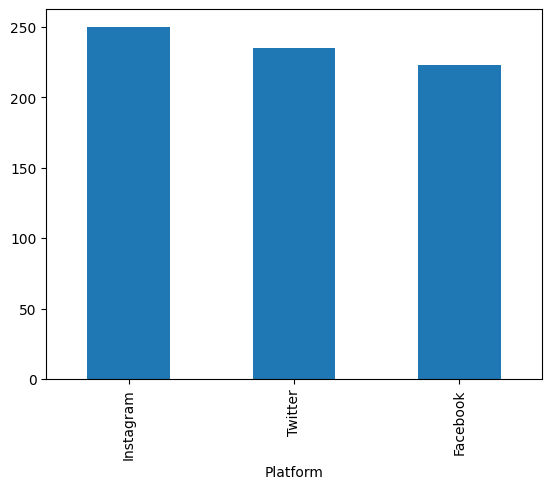

In [95]:
print('Social media platform distribution graph')
df['Platform'].value_counts().plot(kind='bar')


**Comment**: The social media platform distributions are roughly equal

In [96]:
#Sentiment distribution (This is the target variable):
print('text sentiment distributions')
df['text_sentiment'].value_counts()


text sentiment distributions


text_sentiment
Positive    445
Negative    182
Neutral      81
Name: count, dtype: int64

**Comment**: Majority of the sentiments are Positive-based

In [97]:
#Top 10 most common hashtags:
all_tags = [tag for tags in df['hashtag_parsed'] for tag in tags]
Counter(all_tags).most_common(10)

[('Serenity', 15),
 ('Excitement', 13),
 ('Gratitude', 12),
 ('Despair', 11),
 ('Nostalgia', 11),
 ('Curiosity', 10),
 ('Awe', 9),
 ('Contentment', 9),
 ('Grief', 9),
 ('Enthusiasm', 8)]

## Section 2: Network construction & Analysis:

### Graph 1: User-user connection by shared hashtags

In [98]:
G = nx.Graph()

#Adding unique users as the node with sentiment as an attribute:
for _, row in df.iterrows():
    user = row['User']
    if not G.has_node(user):
        G.add_node(
            user,
            platform=row['Platform'],
            sentiment=row['text_sentiment'])

#Create a set of hashtag for user mapping:
hashtag_to_user = {}
for _, row in df.iterrows():
    user = row['User']
    for tag in row['hashtag_parsed']:
        if tag not in hashtag_to_user:
            hashtag_to_user[tag] = set()
        hashtag_to_user[tag].add(user)

#Connect users with at least one hashtag in common and the edge weight = number of shared hashtags between the pair:
for tag, users in hashtag_to_user.items():
    user_list = list(users)
    for u1, u2 in combinations(user_list, 2):
        if G.has_edge(u1, u2):
            G[u1][u2]['weight'] +=1
        else:
            G.add_edge(u1, u2, weight=1)

print(f'Number of nodes (users): {G.number_of_nodes()}')
print(f'Number of edges (shared-hashtag connections): {G.number_of_edges()}')

Number of nodes (users): 670
Number of edges (shared-hashtag connections): 1169


### Compute degree centrality to find which Users have the most connections — i.e., have the most common hashtags with other users. Node size in the plot reflects centrality score.

In [99]:
centrality = nx.degree_centrality(G)
top_10 = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
display(top_10)

top_10_nodes = [node[0] for node in top_10]

[('ForestDreamer', 0.028400597907324365),
 ('NatureAdmirer', 0.02391629297458894),
 ('BookLover3', 0.02391629297458894),
 ('ZenMaster2', 0.022421524663677132),
 ('ExcitementFan', 0.02092675635276532),
 ('MusicLover4', 0.02092675635276532),
 ('SunsetWatcher2', 0.02092675635276532),
 ('NatureSoul', 0.02092675635276532),
 ('OceanSoul', 0.02092675635276532),
 ('RaindropHarmony', 0.02092675635276532)]

### Network plot where: 
1) Nodes = Users, 
2) Edges = shared hashtag connections
3) Node SIZE = degree centrality (how many other users this user is connected to)
4) Labels = Top 10 most-connected users

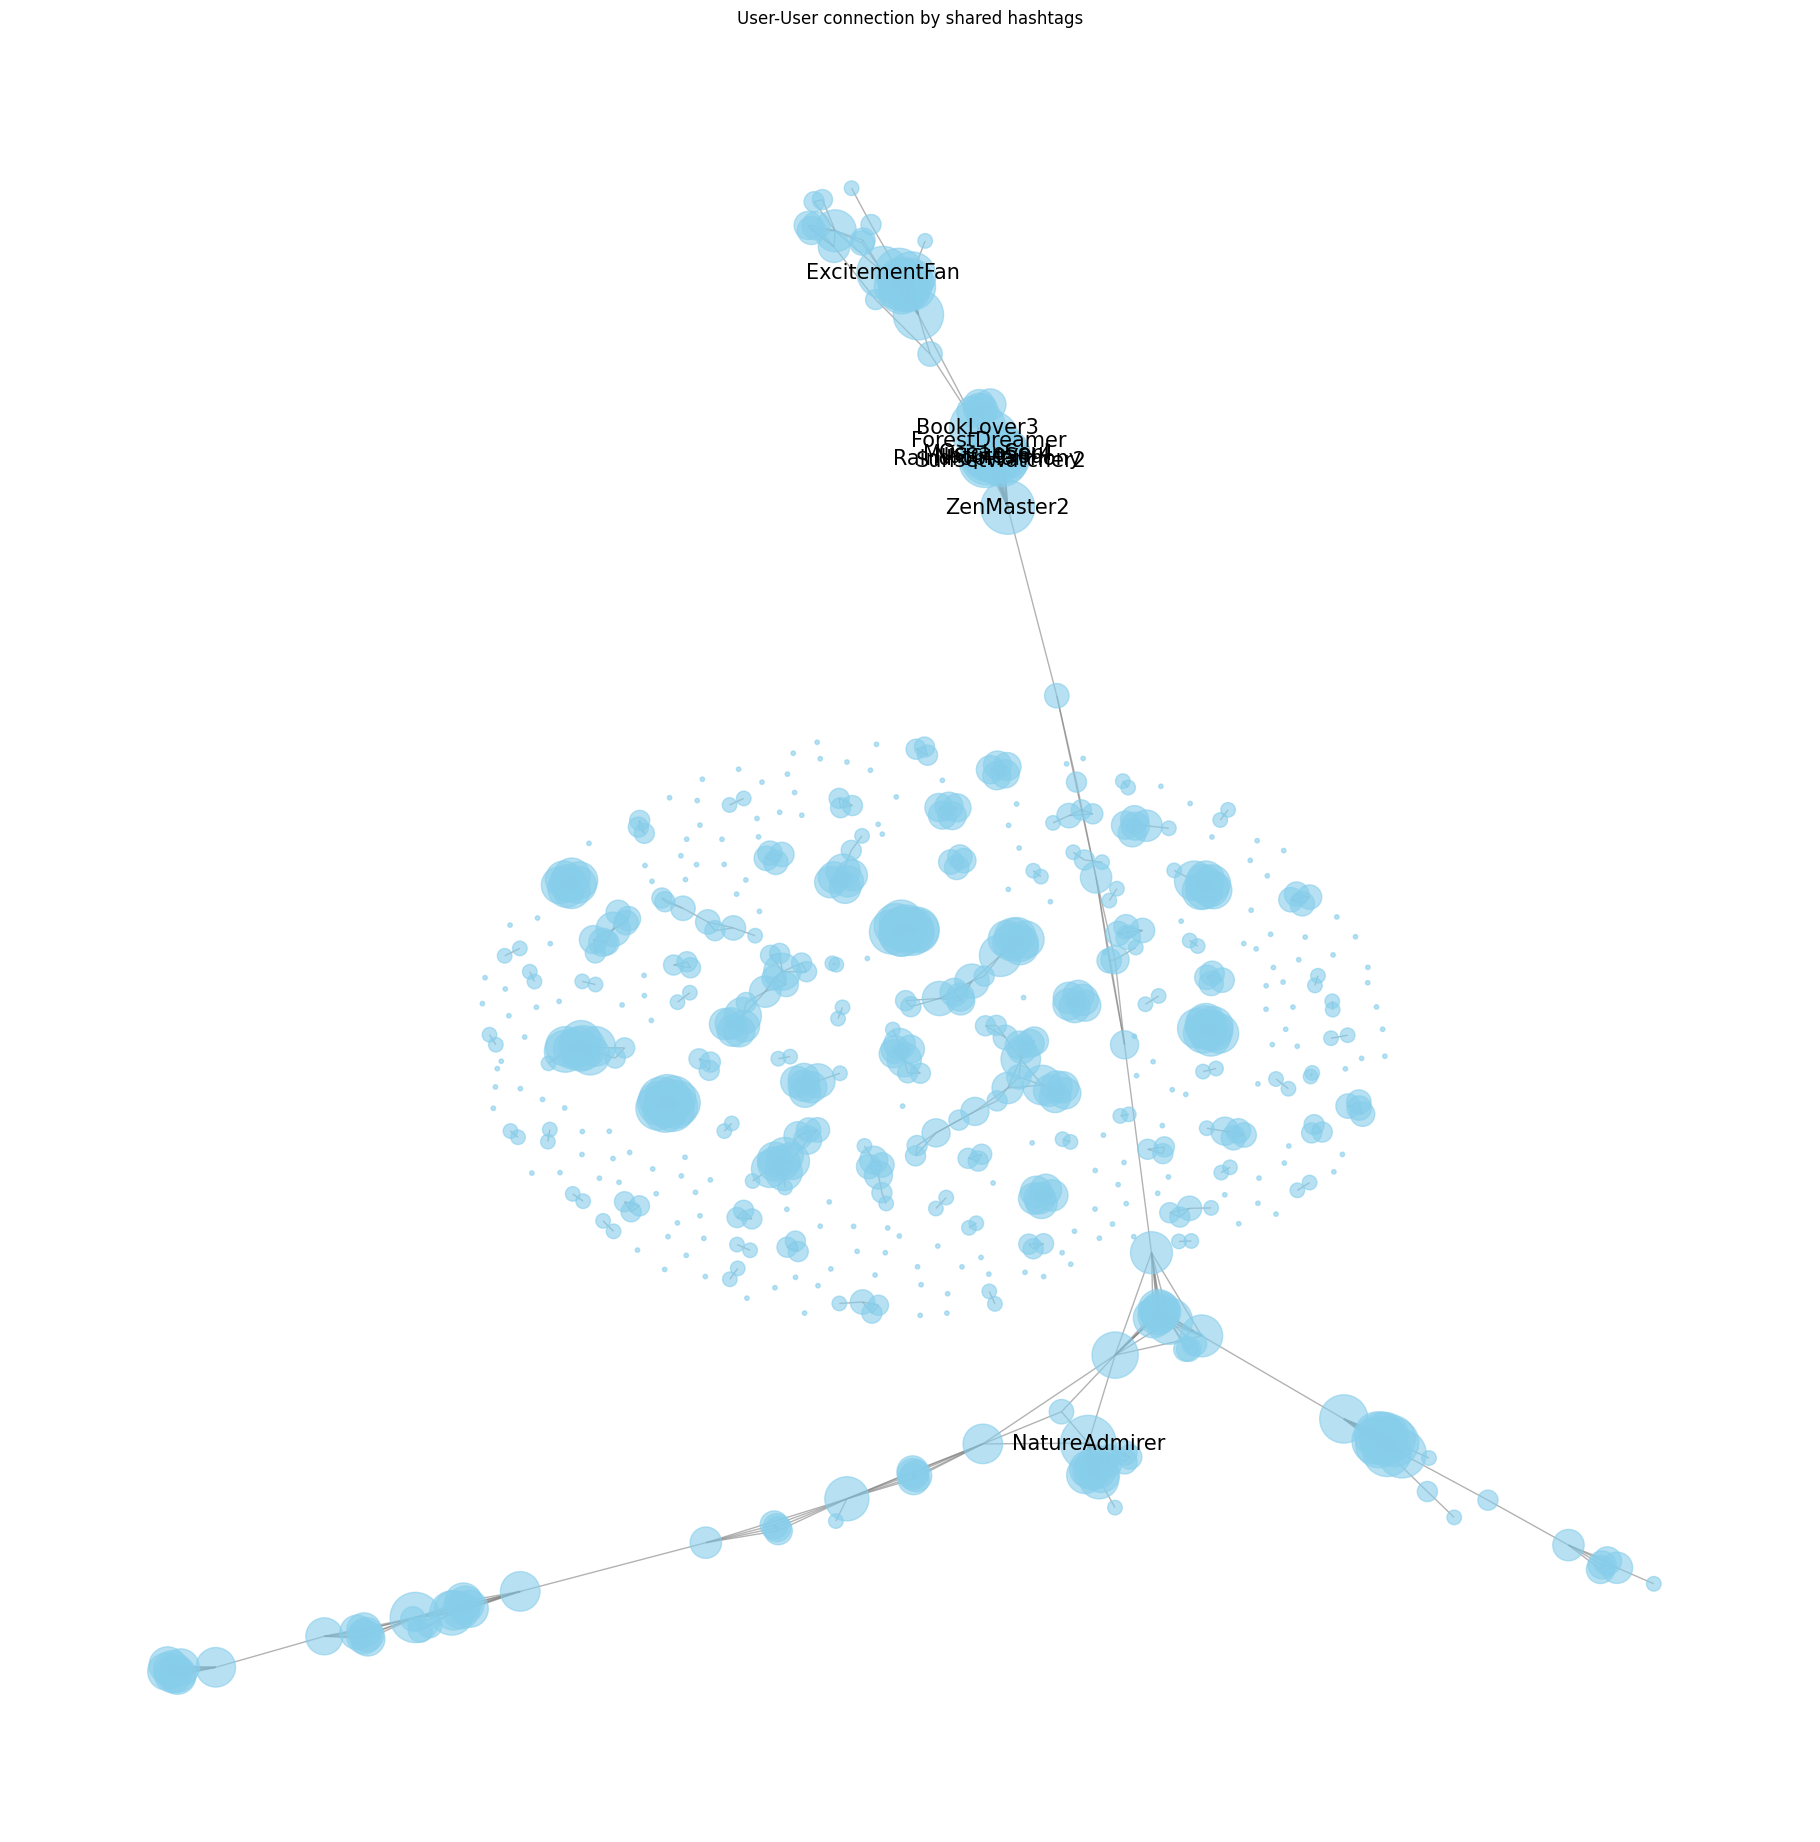

In [100]:
plt.figure(figsize=(18, 18))

degrees = dict(G.degree())

#Scale the node sizes:
node_sizes = [size * 100 + 10 for size in degrees.values()]

#Create node dict that is only in the top 10 list:
top_10_labels = {node: (node if node in top_10_nodes else '') for node in G.nodes}

pos = nx.spring_layout(G, k=0.9, iterations=80)

nx.draw(G, pos=pos, node_size=node_sizes, node_color='skyblue', edge_color='grey', with_labels=False, alpha=0.6)
nx.draw_networkx_labels(G, pos=pos, labels=top_10_labels, font_size=15)
plt.title('User-User connection by shared hashtags')
plt.show()

**Comment:** The labels in the network graph are the top 10 Users with the highest degree centrality.

### Measure the number of community in this dataset:

In [101]:
#Group users to the number of communities that they belong:
partition = community_louvain.best_partition(G)

#Add community as an attribute:
nx.set_node_attributes(G, partition, 'community')

print(f'Number of communities detected: {len(set(partition.values()))}')


Number of communities detected: 268


## Section 3: Network integration and sentiment

### Post sentiments shared by the communities

In [102]:
#Add the number of community back to the df
df['community_num'] = df['User'].map(partition)

#Sentiment by community:
sentiment_by_community = df.groupby(['community_num', 'text_sentiment']).size().unstack(fill_value=0)


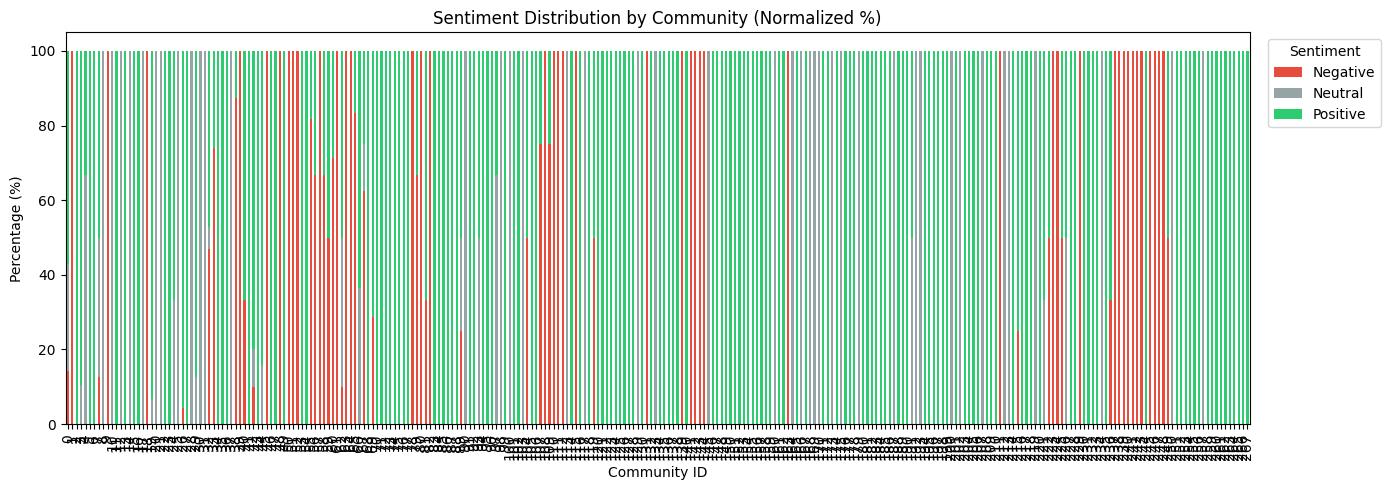

In [103]:
# Normalize to 100% for proportional comparison
sentiment_pct = sentiment_by_community.div(
    sentiment_by_community.sum(axis=1), axis=0
) * 100
# Plot normalized stacked bar (all communities)
ax = sentiment_pct.plot(
    kind='bar', stacked=True, figsize=(14, 5),
    color={'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#2ecc71'}
)
plt.title('Sentiment Distribution by Community (Normalized %)')
plt.xlabel('Community ID')
plt.ylabel('Percentage (%)')
plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Comment**: Majority of the sentiments are positives.

### *Do users who share hashtag communities on social media exhibit similar sentiment patterns*?
#### We can use Chi Square test between communities and text sentiment within each community.
#### ***The Null hypothesis***: All the communities in the social network has no statistical meaningful difference in user sentiments.
#### ***The Alternative hypothesis***: All the communities in the social network show statistical meaningful difference in user sentiments.

In [104]:
#Compute the Chi Square test on user-level:
user_dominant = df.groupby('User')['text_sentiment'].agg(lambda x: x.value_counts().idxmax())

user_level = pd.DataFrame({
    'community': user_dominant.index.map(partition),
    'sentiment': user_dominant.values
})

contingency = pd.crosstab(user_level['community'], user_level['sentiment'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f'Chi-Square: {chi2:.3f}, p-vale:{p}')

Chi-Square: 958.236, p-vale:1.448459084597093e-26


**Comment**: Since the p-value is << 0.05, we can reject the null hypothesis and accept the alternative hyperthesis that communities show significantly different sentiment distributions, suggesting shared hashtag communities are associated with shared senitment tendencies.

### Let us examin the community sentiments of the top 10 well-connected users:

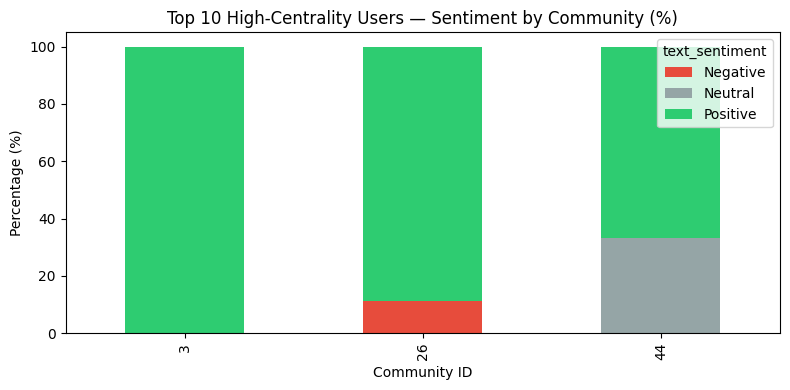

text_sentiment  Negative  Neutral  Positive
community_num                              
3                      0        0         1
26                     1        0         8
44                     0        1         2


In [105]:
top_10_user_comm = (
    df[df['User'].isin(top_10_nodes)]
      .groupby(['community_num', 'text_sentiment'])
      .size()
      .unstack(fill_value=0)
)
# Normalized version for top-10 communities
top10_pct = top_10_user_comm.div(
    top_10_user_comm.sum(axis=1), axis=0
) * 100
ax2 = top10_pct.plot(
    kind='bar', stacked=True, figsize=(8, 4),
    color={'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#2ecc71'}
)
plt.title("Top 10 High-Centrality Users — Sentiment by Community (%)")
plt.xlabel('Community ID')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()
# Raw counts table
print(top_10_user_comm)

**Comment**: Majority of the top 10 users lean towards positive sentiment as refected by the overall structure of the dataset.

#### Cross-tabulations for each platform:

Platform,Facebook,Instagram,Twitter
community_num,,,
0,4,4,6
1,0,0,1
2,0,1,1
3,9,9,11
4,1,2,0
...,...,...,...
263,0,1,0
264,0,0,1
265,1,0,0


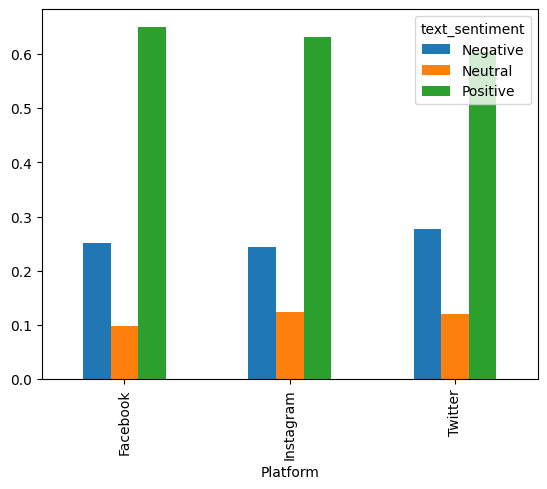

In [106]:
# Platform vs Sentiment
pd.crosstab(df['Platform'], df['text_sentiment'], normalize='index').plot(kind='bar')
# Community vs Platform
pd.crosstab(df['community_num'], df['Platform'])

**Comment**:The sentiment distributions for each Platfor is relatively equal.

## Section 4: Predictive Modeling

### Feature engineering: Combine both network features and text features to train ML models

In [107]:
#Add degree centrality to the dataframe:
df['centrality'] = df['User'].map(centrality)

#Encode the target variables to numbers:
target_labels = {'Positive' : 1, 'Negative': 0, 'Neutral': -1}
df['target_labels'] = df['text_sentiment'].map(target_labels)
y = df['target_labels']

#Add oneHotEncoder to categorical columns
community_dummies = pd.get_dummies(df['community_num'], prefix='comm', dtype=int) #"community_num" need OneHotEncoding since these are just labels for the communities:
platform_dummies = pd.get_dummies(df['Platform'], prefix='platform', dtype=int) 
country_dummies = pd.get_dummies(df['Country'], prefix='country', dtype=int)

#Add to the existing dataframe:
df = pd.concat([df, community_dummies, platform_dummies, country_dummies], axis=1)

#Additional features:
df['log_likes']    = np.log1p(df['Likes'])
df['log_retweets'] = np.log1p(df['Retweets'])

#Other network features:
betweenness  = nx.betweenness_centrality(G)
clustering   = nx.clustering(G)
degrees = dict(G.degree())

df['betweenness'] = df['User'].map(betweenness)
df['clustering'] = df['User'].map(clustering)
df['degree'] = df['User'].map(degrees)

### Train Test Split

In [108]:
#Adding scaler for SGD for scaled data:
scaler = MaxAbsScaler()

#Trai test split first before vectorizing the text:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y)

#Perform TFIDF to extract features from the text posts:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

tfidf_train = tfidf_vectorizer.fit_transform(X_train['Text'])
tfidf_test = tfidf_vectorizer.transform(X_test['Text'])

#Define the text feature only train and test set:
X_train_text = scaler.fit_transform(tfidf_train)
X_test_text = scaler.transform(tfidf_test)

#All the extra features OneHot columns + numeric columns:
#Dummy columns + num columns:
dummy_col = list(community_dummies.columns) + list(platform_dummies.columns) + list(country_dummies.columns)
num_col = ['centrality', 'betweenness', 'clustering', 'degree', 'log_likes', 'log_retweets']
all_extra_cols = num_col + dummy_col

#Split network features:
train_net = sp.csr_matrix(X_train[all_extra_cols].values)
test_net = sp.csr_matrix(X_test[all_extra_cols].values)

#Combine text features and network features into train and test set:
X_train_full = sp.hstack([tfidf_train, train_net])
X_test_full = sp.hstack([tfidf_test,  test_net])

### Can we predict post sentiment from both textual content and network position?
#### To answewr this question, 3 ML algorithms were selected:
#### Logistic Regression:
    Pros: 1) Fast to train with TF-IDF sparse matrices
          2) High interpretable at features-level
          3) Low risk of overfitting with L1/L2 regularization

    Cons: 1) Assumes linear boundary decision. Results might suffer if there's complex pattern
          2) Sensitive to correlated/redundant features
          3) Requires scaling.

#### Randomforest:
    Pros: 1) Robust to outliners and features (scaling not needed)
          2) Handles class imbalance with "class_weight" option
          3) Captures non-linear relationships
          4) Less prone to overfitting

    Cons: 1) High computational cost with high dimensional sparese TF-IDF
          2) Less interpretable at feature-level
          3) Requires tuning for small dataset

#### SGD:
    Pros: 1) Extremely fast on large, sparse datasets (ideal for TF-IDF)
          2) Scales well to many features + samples

    Cons: 1) Require scaling of features
          2) Less reproducible due to stochastic nature
          3) Hard to tune. May require many iterations to converge

Three machine learning models — Logistic Regression, Random Forest, and SGD — were trained and evaluated in two stages: first using text features alone as a baseline, then using a combined feature set of text and network-derived metrics. This two-stage design allows for a direct comparison of model performance and reveals whether the inclusion of network features meaningfully improves classification outcomes.

The macro-averaged F1 score was selected as the primary evaluation metric given the imbalanced class distribution in the target variable, where positive sentiments constitute the majority class. Accuracy is an unreliable metric under class imbalance, as it is dominated by the majority class and can yield misleadingly high scores even when minority classes are poorly classified. The macro-averaged F1 score addresses this limitation by computing the F1 score — the harmonic mean of precision and recall — independently for each class and averaging the results with equal weight, regardless of class size. This ensures that model performance is assessed uniformly across all sentiment classes, penalizing models that neglect underrepresented labels.

#### Baseline text features only model:

In [120]:
classifers = {
    'logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=1000, random_state=42, class_weight='balanced_subsample'),
    'SGD': SGDClassifier(loss='modified_huber', random_state=42, max_iter=1000, class_weight='balanced')
}

#Target label names:
inv_labels = {v: k for k, v in target_labels.items()}
correct_names = [inv_labels[l] for l in sorted(inv_labels)]

results = {}
for name, clf in classifers.items():
    clf.fit(X_train_text, y_train)
    y_pred = clf.predict(X_test_text)
    print('-'*40)
    print(f"{name}")
    print('-'*40)
    print(classification_report(y_test, y_pred, target_names=correct_names))
    print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")
    results[name] = clf

----------------------------------------
logistic Regression
----------------------------------------
              precision    recall  f1-score   support

     Neutral       0.44      0.25      0.32        16
    Negative       0.88      0.76      0.81        37
    Positive       0.80      0.91      0.85        89

    accuracy                           0.80       142
   macro avg       0.71      0.64      0.66       142
weighted avg       0.78      0.80      0.78       142

Macro F1: 0.661
----------------------------------------
Random Forest
----------------------------------------
              precision    recall  f1-score   support

     Neutral       0.25      0.06      0.10        16
    Negative       0.94      0.41      0.57        37
    Positive       0.70      0.97      0.82        89

    accuracy                           0.72       142
   macro avg       0.63      0.48      0.49       142
weighted avg       0.71      0.72      0.67       142

Macro F1: 0.494
--------

**Comment:** The most model from the text processing feature alone is SGD, which has the average F1 macro score of 0.67.

## Since SGD performed the best, we can extract the most important features and also look at the most frequently appearing words within the three target variable classes:

In [123]:
# 1. Combine text features and network/dummy features to match X_train_full
text_features = list(tfidf_vectorizer.get_feature_names_out())
SGD = results['SGD']

# 2. Grab the specific Logistic Regression model from the results dict
print("Top 10 frequently appearing words the from SGD:")
for i, cls in enumerate(SGD.classes_):
    top_idx = SGD.coef_[i].argsort()[-10:][::-1]
    print(f'Class: {inv_labels[cls]} -- Top 10 features: {[text_features[j] for j in top_idx]}')

Top 10 frequently appearing words the from SGD:
Class: Neutral -- Top 10 features: ['scenic', 'writing', 'embarking', 'mysteries', 'enveloped', 'exploring', 'breeze', 'transported', 'local', 'spent']
Class: Negative -- Top 10 features: ['frustration', 'chaos', 'resentment', 'disappointment', 'loss', 'crucial', 'forgotten', 'fearful', 'disappointed', 'indifference']
Class: Positive -- Top 10 features: ['love', 'heart', 'thrill', 'beauty', 'laughter', 'wasteland', 'growth', 'exotic', 'grandeur', 'cherished']


**Comment:** The frequently appearing words in each class match with their corresponding sentiments such as love, heart, laughter to positive and frustration, chaos, resentment, to negative sentiments.

#### Full features text + network position

In [111]:
classifers = {
    'logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=1000, random_state=42, class_weight='balanced_subsample'),
    'SGD': SGDClassifier(loss='modified_huber', random_state=42, max_iter=1000, class_weight='balanced')
}

#Target label names:
inv_labels = {v: k for k, v in target_labels.items()}
correct_names = [inv_labels[l] for l in sorted(inv_labels)]

results = {}
for name, clf in classifers.items():
    clf.fit(X_train_full, y_train)
    y_pred = clf.predict(X_test_full)
    print('-'*40)
    print(f"{name}")
    print('-'*40)
    print(classification_report(y_test, y_pred, target_names=correct_names))
    print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")
    results[name] = clf

----------------------------------------
logistic Regression
----------------------------------------
              precision    recall  f1-score   support

     Neutral       0.38      0.38      0.38        16
    Negative       0.80      0.76      0.78        37
    Positive       0.84      0.85      0.84        89

    accuracy                           0.77       142
   macro avg       0.67      0.66      0.67       142
weighted avg       0.77      0.77      0.77       142

Macro F1: 0.666
----------------------------------------
Random Forest
----------------------------------------
              precision    recall  f1-score   support

     Neutral       0.50      0.06      0.11        16
    Negative       0.95      0.49      0.64        37
    Positive       0.73      0.99      0.84        89

    accuracy                           0.75       142
   macro avg       0.72      0.51      0.53       142
weighted avg       0.76      0.75      0.71       142

Macro F1: 0.531
--------

**Comment :** The best model for the combination of Network and text processing features is Logistic Regression, which has average F1 macro score of 0.67. In comparison to the baseline ML SGD (with text processing alone), the combination of Network and text processing did not yield any meaningful difference-- both showed F1 macro score of 0.67.

## Can Network position predict user sentiment? In other words, do people's text sentiments get affected by their neighbors?
### We can explore this question by defining additional features on the user-level.

In [112]:
def neighbor_pos_ratio(user):
    neighbors = list(G.neighbors(user))
    if not neighbors:
        return 0.5
    return (df[df['User'].isin(neighbors)]['text_sentiment'] == 'Positive').mean()

user_net = df.groupby('User').agg(
    num_posts = ('Text', 'count'),
    avg_likes = ('Likes', 'mean'),
    avg_retweets = ('Retweets', 'mean'),
    avg_hashtags = ('hashtag_parsed', lambda x: np.mean([len(h) for h in x]))
).reset_index()

#Map platform and country to user-level from df:
user_platform = df.drop_duplicates('User').set_index('User')['Platform']
user_country  = df.drop_duplicates('User').set_index('User')['Country']

#Adding additional features:
user_net['log_avg_likes']    = np.log1p(user_net['avg_likes'])
user_net['log_avg_retweets'] = np.log1p(user_net['avg_retweets'])
user_net['is_single_post']   = (user_net['num_posts'] == 1).astype(int)
user_net['centrality']       = user_net['User'].map(centrality)
user_net['betweenness']      = user_net['User'].map(betweenness)
user_net['clustering']       = user_net['User'].map(clustering)
user_net['degree']           = user_net['User'].map(degrees)
user_net['neighbor_pos_ratio'] = user_net['User'].apply(neighbor_pos_ratio)
user_net['Platform'] = user_net['User'].map(user_platform)
user_net['Country']  = user_net['User'].map(user_country)

#OnHotEncode community + platform
community_dummies = pd.get_dummies(user_net['User'].map(partition), prefix='comm', dtype=int)
platform_dummies = pd.get_dummies(user_net['Platform'], prefix='platform', dtype=int) 
country_dummies = pd.get_dummies(user_net['Country'], prefix='country', dtype=int)
user_net = pd.concat([user_net, community_dummies, platform_dummies, country_dummies], axis=1)
user_net = user_net.drop(columns=['Platform', 'Country']) #Drop the original columns

#Target variable - dominant sentiment, derived independently of features above
user_dominant = df.groupby('User')['text_sentiment'].agg(
    lambda x: x.value_counts().idxmax()
)

user_net['label'] = user_net['User'].map(user_dominant)


In [113]:
print(user_net['label'].value_counts())
print(f"Total users: {len(user_net)}")

label
Positive    422
Negative    175
Neutral      73
Name: count, dtype: int64
Total users: 670


**Comment:** The distribution of the labels are not balanced. We will have to address this imbalance when defining the ML algorithms.

In [114]:
X = user_net.drop(['label', 'User'], axis=1) #Dropped the User names and the target variable such as the 'label' column.
y = user_net['label'] #Define the target variable column
X_train_user_net, X_test_user_net, y_train_user_net, y_test_user_net = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#Scaling the data:
X_train_sc = scaler.fit_transform(X_train_user_net)
X_test_sc = scaler.transform(X_test_user_net)

In [115]:
#The class_weight option was used to mitigate the class imbalance effects.
classifers = {
    'logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=1000, random_state=42, class_weight='balanced_subsample'),
    'SGD': SGDClassifier(loss='modified_huber', random_state=42, max_iter=1000, class_weight='balanced')
}

#Target label names:
inv_labels = {v: k for k, v in target_labels.items()}
correct_names = [inv_labels[l] for l in sorted(inv_labels)]

results = {}
for name, clf in classifers.items():
    clf.fit(X_train_sc, y_train_user_net)
    y_pred = clf.predict(X_test_sc)
    print('-'*40)
    print(f"{name}")
    print('-'*40)
    print(classification_report(y_test_user_net, y_pred, target_names=correct_names))
    print(f"Macro F1: {f1_score(y_test_user_net, y_pred, average='macro'):.3f}")
    results[name] = clf

----------------------------------------
logistic Regression
----------------------------------------
              precision    recall  f1-score   support

     Neutral       0.77      0.69      0.73        35
    Negative       0.33      0.47      0.39        15
    Positive       0.80      0.79      0.80        84

    accuracy                           0.72       134
   macro avg       0.64      0.65      0.64       134
weighted avg       0.74      0.72      0.73       134

Macro F1: 0.637
----------------------------------------
Random Forest
----------------------------------------
              precision    recall  f1-score   support

     Neutral       0.82      0.66      0.73        35
    Negative       0.00      0.00      0.00        15
    Positive       0.75      0.94      0.83        84

    accuracy                           0.76       134
   macro avg       0.52      0.53      0.52       134
weighted avg       0.68      0.76      0.71       134

Macro F1: 0.521
--------

c:\Users\godly\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\godly\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\godly\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

**Comment**: The Logistic Regression model is able to get as close to the text feature prediction (0.64 vs. 0.67 in F1 Macro score, respectively) without using a single text feature. This suggests that the hashtag network encodes meaningful behavioral signals about how users express sentiment, independent of linguistic content. 

## Conclusion:
In this study, we demonstrated that hashtag communities exhibit significantly different sentiment distributions (Chi-Square, p << 0.05). This is a meaningful finding because while the network was constructed based on shared hashtags, it does not guarantee shared sentiment — users can share hashtags for different reasons. The result confirms that hashtag communities capture genuine sentiment homophily beyond mere topical overlap.

For post-level sentiment prediction, text features alone were sufficient, with network features adding no meaningful improvement. This is expected: network features describe user-level social structure and cannot distinguish why one individual post is positive while another is negative.

For user-level sentiment prediction, the logistic regression model achieved a Macro F1 score of 0.63 — approaching the 0.67 achieved by text features on post-level prediction. Although the two scores are not directly comparable due to differences in sample granularities and sizes, we demonstrated that social network position encodes meaningful behavioral signals about user dominant sentiments. In other words, a user's sentiment can, indeed, be influenced by his or her neighbors in the social network, independent of linguistic content.

Limitations
One limitation was the sentiment labeling approach. The original dataset contained over 200 unique sentiment labels, unsuitable for classification. We re-labeled the text sentiments using VADER polarity scores and validated against the original labels, achieving 71.6% agreement — considered acceptable given the subjective nature of sentiment and the inherent ambiguity of collapsing 200+ categories into three. Additionally, the Negative class consistently showed the lowest F1 scores across both tasks, reflecting its smaller representation in the dataset rather than a modeling failure. The neighbor_pos_ratio variable is derived from text_sentiment, which creates a confounder with user_dominant — this is not data leakage, but may have partially contributed to the 0.63 F1 score.

A further limitation concerns the provenance of the dataset. The Kaggle dataset used in this study is widely suspected to be synthetically generated rather than scraped from real social media activity. Evidence of this emerged during the NLP analysis: the top TF-IDF features per sentiment class, while semantically coherent (e.g., "frustration" and "chaos" for Negative, "love" and "laughter" for Positive), may reflect artificially constructed co-occurrence patterns rather than organic language use. In a genuine social media corpus, sentiment signal is noisier and more context-dependent, which would likely lower the F1 ceiling below the 0.67 observed here. Additionally, the need to re-label over 200 sentiment categories via VADER — a step that would be unnecessary with a well-sourced real-world dataset — further suggests the original labels lacked systematic provenance. Future work should validate these findings on a verified organic corpus such as the SemEval Twitter sentiment dataset or a directly scraped dataset, to assess whether network-sentiment homophily and the predictive power of network position hold under more realistic linguistic conditions.